# **Part 1** — Using K-Means to cluster unlabeled customer data

## Problem Statement:
Imagine we are working for a distributor. The company knows how much each customer has spent 
on milk, vegetables, frozen food, etc. However, no one has grouped them into specific categories yet, 
such as "grocery shoppers" or "traditional food shoppers".

## Notebook Workflow:
Unlabeled data 
→ Clean and scale metrics 
→ K-Means clustering 
→ Human inspection & labeling 
→ Export labeled data for KNN.


## **I. Libraries and Data**

In [4]:
from pathlib import Path
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
RANDOM_STATE = 42

In [5]:
df = pd.read_csv("wholesale_customers.csv")

## **II. Getting Familiar with the Data**

Before applying the algorithm, we need to answer three simple questions:
- Are there any columns with missing data?
- What is the data type of each column?
- How large is the spending gap between different product categories?

The six spending columns often contain a few customers who spend significantly more than the rest. 
We use 'log1p' to "compress" these extremely large values, similar to zooming out on a map 
to see both nearby and distant points. After that, 'StandardScaler' is used to bring all columns 
to the same scale, preventing columns with larger numbers from automatically dominating the others.


In [6]:
FEATURES = [
    "Fresh", "Milk", "Grocery", "Frozen",
    "Detergents_Paper", "Delicassen"
]

quality_report = pd.DataFrame({
    "dtype": df[FEATURES].dtypes.astype(str),
    "missing": df[FEATURES].isna().sum(),
    "unique": df[FEATURES].nunique(),
})
display(quality_report)
display(df[FEATURES].describe().T.round(1))

,dtype,missing,unique
Fresh,int64,0,433
Milk,int64,0,421
Grocery,int64,0,430
Frozen,int64,0,426
Detergents_Paper,int64,0,417
Delicassen,int64,0,403


,count,mean,std,min,25%,50%,75%,max
Fresh,440.0,12000.3,12647.3,3.0,3127.8,8504.0,16933.8,112151.0
Milk,440.0,5796.3,7380.4,55.0,1533.0,3627.0,7190.2,73498.0
Grocery,440.0,7951.3,9503.2,3.0,2153.0,4755.5,10655.8,92780.0
Frozen,440.0,3071.9,4854.7,25.0,742.2,1526.0,3554.2,60869.0
Detergents_Paper,440.0,2881.5,4767.9,3.0,256.8,816.5,3922.0,40827.0
Delicassen,440.0,1524.9,2820.1,3.0,408.2,965.5,1820.2,47943.0


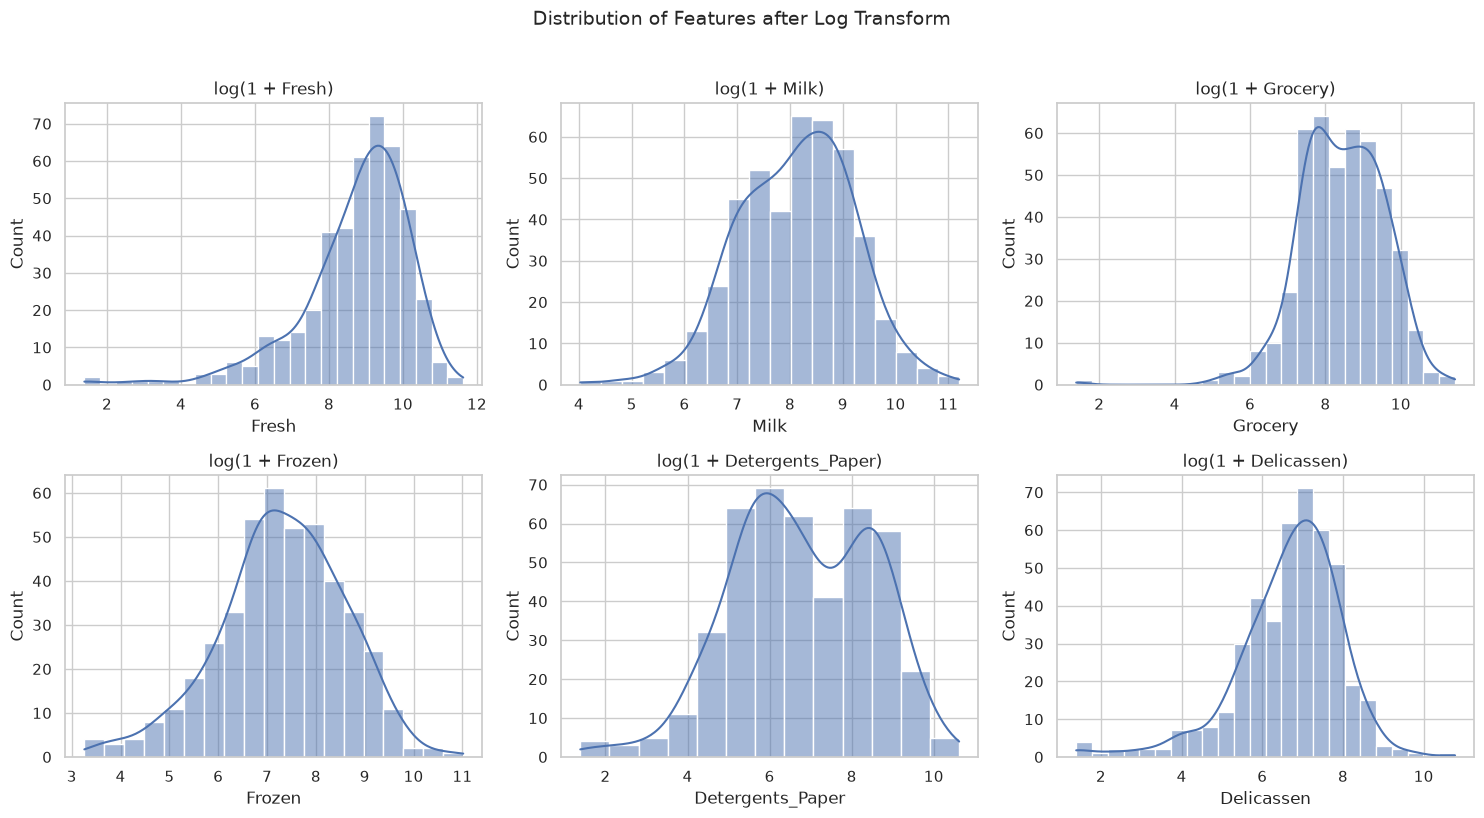

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for column, ax in zip(FEATURES, axes.flat):
    sns.histplot(np.log1p(df[column]), kde=True, ax=ax)
    ax.set_title(f"log(1 + {column})")
plt.suptitle("Distribution of Features after Log Transform", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## **III. How many clusters should K-Means create?**

K-Means requires us to specify the number of clusters in advance, denoted as 'k'. 
We experiment with k ranging from 2 to 8 and evaluate three metrics:

- Inertia: Are customers within the same cluster close to each other? Smaller is better, 
  but this metric always decreases as more clusters are added.
- Silhouette: Does a customer look more like their own cluster than other clusters? 
  Closer to 1 is better; closer to 0 means boundaries are overlapping and blurry.
- Calinski-Harabasz: Compares the internal tightness of clusters with the separation 
  between different clusters. Larger values are generally better.

The Silhouette metric might favor k=2, but two clusters are often too few for the marketing team 
to take distinct actions. We choose k=3 as a balanced decision between mathematical quality 
and practical business needs. This is an important example: metrics support decisions; 
they do not replace human judgment.


In [10]:
preprocessor = Pipeline([
    ("log1p", FunctionTransformer(np.log1p, feature_names_out="one-to-one")), #better normalization
    ("scaler", StandardScaler())
])
X_scaled = preprocessor.fit_transform(df[FEATURES])
rows = []
models = {}
for k in range(2, 9): #2-> 8 clusters
    model = KMeans(n_clusters=k, n_init = 20,random_state=42)
    labels = model.fit_predict(X_scaled)
    models[k] = model
    # Silhouette: Evaluates each individual point to see if it is close to its 
    # assigned cluster and far from other clusters.
    # - Value range: [-1, 1]
    # - Closer to 1 => Highly accurate; Closer to -1 => Misclustered.

    # Calinski-Harabasz: Evaluates the entire dataset by comparing the variance 
    # between clusters against the variance within each individual cluster.
    # - Value range: 0 to +infinity (Larger values indicate better clustering).
    rows.append({
        "k": k,
        "inertia": model.inertia_,
        "silhouette": silhouette_score(X_scaled, labels),
        "calinski_harabasz": calinski_harabasz_score(X_scaled, labels)
    })
k_report = pd.DataFrame(rows) 
k_report.round(3)



,k,inertia,silhouette,calinski_harabasz
0,2,1844.064,0.290,189.050
1,3,1553.413,0.258,152.837
2,4,1386.863,0.188,131.320
3,5,1266.149,0.192,118.000
4,6,1174.536,0.195,108.300
5,7,1086.359,0.196,103.208
6,8,1024.047,0.191,97.386


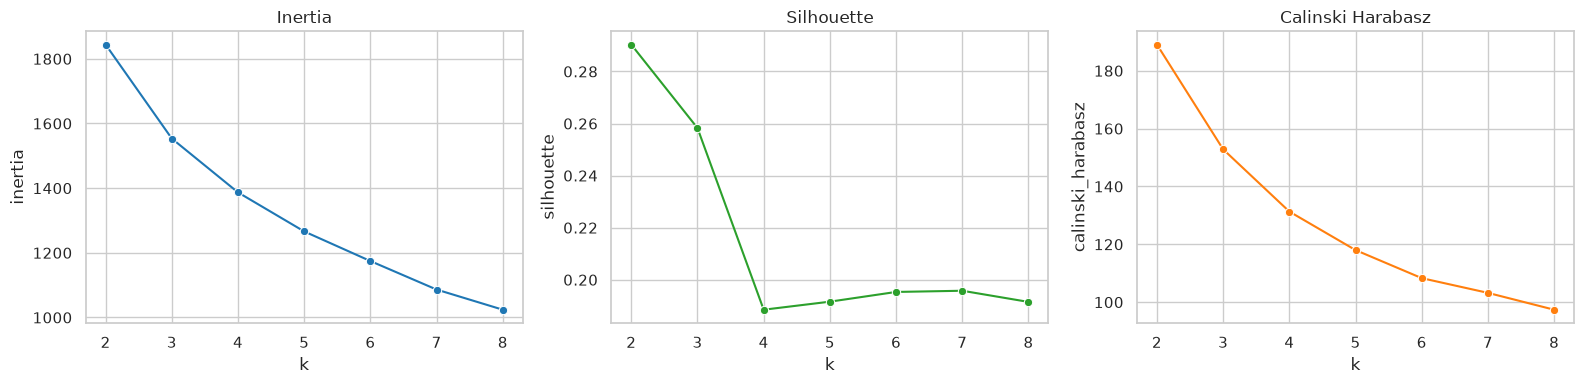

k tốt nhất theo Silhouette: 2
k được chọn sau khi cân bằng chất lượng và nhu cầu nghiệp vụ: 3


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for metric, ax, color in zip(
    ["inertia", "silhouette", "calinski_harabasz"],
    axes, ["tab:blue", "tab:green", "tab:orange"]
):
    sns.lineplot(data=k_report, x="k", y=metric, marker="o", ax=ax, color=color)
    ax.set_title(metric.replace("_", " ").title())
plt.tight_layout()
plt.show()

best_silhouette_k = int(k_report.loc[k_report["silhouette"].idxmax(), "k"])
BUSINESS_K = 3
print(f"Best k by Silhouette: {best_silhouette_k}")
print(f"Chosen k as a balance between mathematical quality and business needs: {BUSINESS_K}")